# Task 5 — Model Evaluation

**Goal:** Formally evaluate the trained SVC using all required and bonus metrics. Produce publication-quality figures for the final report.

**Input:** `data/processed/svc_model.pkl`, `scaler.pkl`, `feature_names.npy`, `compounds_clean.csv`  
**Output:** `results/figures/roc_curve.png`, `results/figures/pr_curve.png`, `results/figures/confusion_matrix_final.png`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    classification_report
)

## 1. Reconstruct the Exact Train / Test Split

We use the same `random_state=42` and `stratify=y` as Task 4 to recover the identical held-out test set. The scaler is loaded from disk so test data is transformed using training statistics only — no leakage.

In [2]:
# Load model and scaler saved by Task 4
svc     = joblib.load('../data/processed/svc_model.pkl')
scaler  = joblib.load('../data/processed/scaler.pkl')

# Load cleaned data and feature list
df           = pd.read_csv('../data/processed/compounds_clean.csv')
feature_names = np.load('../data/processed/feature_names.npy', allow_pickle=True)

X_raw = df[feature_names].values
y     = df['Class'].values
cid   = df['CID'].values

# Reproduce the identical split from Task 4
_, X_test_raw, _, y_test, _, cid_test = train_test_split(
    X_raw, y, cid, test_size=0.2, random_state=42, stratify=y
)

# Transform test set using the training scaler (fit was done on train only in Task 4)
X_test = scaler.transform(X_test_raw)

print(f'Test set : {X_test.shape[0]} compounds  (inactive={(y_test==0).sum()}, active={(y_test==1).sum()})')

Test set : 49 compounds  (inactive=15, active=34)


## 2. Predictions

`predict` returns hard class labels (0 or 1). `decision_function` returns a continuous score — the signed distance from the SVC decision boundary. We need the continuous score to draw the ROC and precision-recall curves.

In [3]:
y_pred   = svc.predict(X_test)

# decision_function gives a continuous score needed for ROC / PR curves
y_scores = svc.decision_function(X_test)

print('Predicted class counts:')
unique, counts = np.unique(y_pred, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Active' if cls == 1 else 'Inactive'
    print(f'  {label} ({cls}): {cnt}')

Predicted class counts:
  Inactive (0): 15
  Active (1): 34


## 3. Required Metrics

The assignment requires accuracy, precision, and recall. We report them per-class and overall.

In [4]:
acc  = accuracy_score(y_test, y_pred)

# Report metrics for the positive class (active compounds, label=1)
prec = precision_score(y_test, y_pred, pos_label=1)
rec  = recall_score(y_test, y_pred, pos_label=1)
f1   = f1_score(y_test, y_pred, pos_label=1)

print('=== Required Metrics ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}  (of compounds predicted active, how many truly are)')
print(f'Recall    : {rec:.4f}  (of all true actives, how many did the model catch)')
print(f'F1        : {f1:.4f}')
print()
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Inactive (0)', 'Active (1)']))

=== Required Metrics ===
Accuracy  : 1.0000
Precision : 1.0000  (of compounds predicted active, how many truly are)
Recall    : 1.0000  (of all true actives, how many did the model catch)
F1        : 1.0000

=== Full Classification Report ===
              precision    recall  f1-score   support

Inactive (0)       1.00      1.00      1.00        15
  Active (1)       1.00      1.00      1.00        34

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



## 4. Bonus Metrics

- **AUC-ROC** — area under the ROC curve. Measures how well the model ranks active compounds above inactive ones across all decision thresholds. 1.0 = perfect, 0.5 = random.
- **MCC (Matthews Correlation Coefficient)** — the most informative single metric under class imbalance. Ranges from -1 (perfectly wrong) to +1 (perfectly correct). Unlike accuracy, it accounts for all four cells of the confusion matrix.

In [5]:
auc = roc_auc_score(y_test, y_scores)
mcc = matthews_corrcoef(y_test, y_pred)

print('=== Bonus Metrics ===')
print(f'AUC-ROC : {auc:.4f}')
print(f'MCC     : {mcc:.4f}')

=== Bonus Metrics ===
AUC-ROC : 1.0000
MCC     : 1.0000


## 5. Confusion Matrix

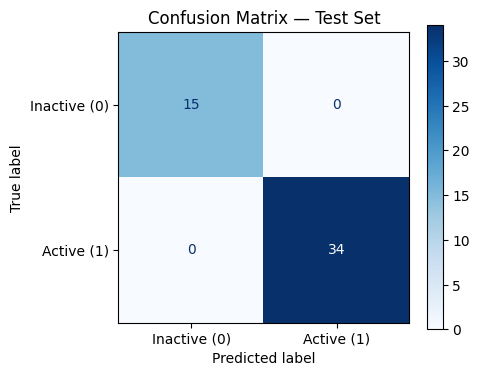

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Inactive (0)', 'Active (1)'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC Curve

The ROC curve plots the true positive rate (recall) against the false positive rate at every possible decision threshold. A perfect classifier hugs the top-left corner. AUC is the area under this curve.

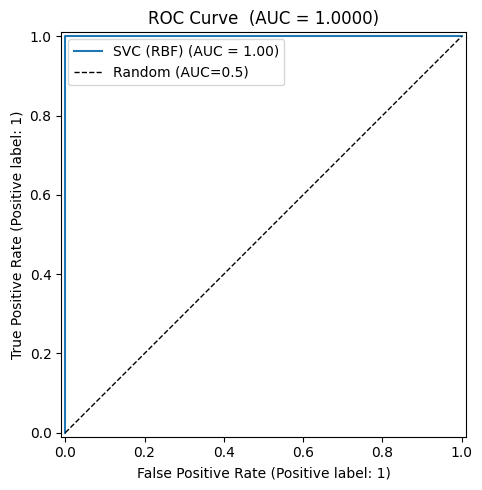

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_scores, pos_label=1, ax=ax, name='SVC (RBF)'
)
# Diagonal reference line — performance of a random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_title(f'ROC Curve  (AUC = {auc:.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Precision-Recall Curve

More informative than ROC under class imbalance. Shows the trade-off between precision and recall as the decision threshold changes. A perfect classifier reaches the top-right corner (precision=1, recall=1).

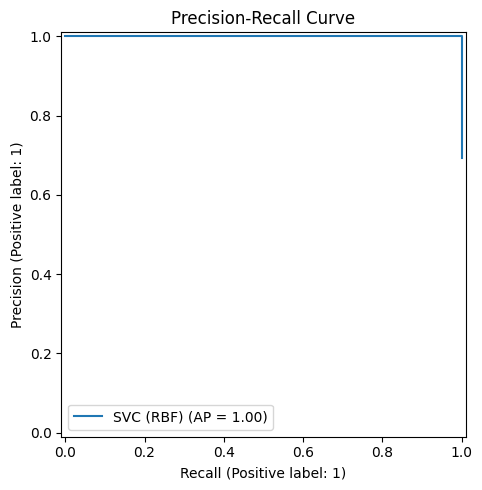

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_scores, pos_label=1, ax=ax, name='SVC (RBF)'
)
ax.set_title('Precision-Recall Curve')
plt.tight_layout()
plt.savefig('../results/figures/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [9]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'MCC'],
    'Value':  [acc, prec, rec, f1, auc, mcc],
    'Required': ['Yes', 'Yes', 'Yes', 'No', 'No', 'No']
})
summary['Value'] = summary['Value'].round(4)
print(summary.to_string(index=False))

   Metric  Value Required
 Accuracy    1.0      Yes
Precision    1.0      Yes
   Recall    1.0      Yes
       F1    1.0       No
  AUC-ROC    1.0       No
      MCC    1.0       No
